In [1]:
from pathlib import Path
import torch
import sys
import numpy as np
from model import src_pkg, REPO_ROOT, RTDETR_PYTORCH_ROOT, RTDETR_SRC_ROOT

sys.modules["src"] = src_pkg
from src.core import YAMLConfig 

/home/uwu/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare the Torch Model from original source

In [2]:
ckpt_path = REPO_ROOT / "models/rtdetr/checkpoints/rtdetr_r18vd_dec3_6x_coco_from_paddle.pth"
checkpoint = torch.load(str(ckpt_path), map_location="cpu")

config = YAMLConfig(
    str(RTDETR_PYTORCH_ROOT / "configs/rtdetr/rtdetr_r18vd_6x_coco.yml"),
    resume=str(ckpt_path),
)

sys.path.append(str(REPO_ROOT))

# NOTE: resume= only stores a path in YAMLConfig; it does NOT load weights into
# config.model (that happens in the RT-DETR solver, which we never instantiate).
# So we must load the state dict explicitly, exactly like models/rtdetr/export.py.
state = checkpoint["ema"]["module"] if "ema" in checkpoint else checkpoint["model"]
load_info = config.model.load_state_dict(state)
print("missing keys:", load_info.missing_keys)
print("unexpected keys:", load_info.unexpected_keys)

model = config.model.deploy().to("cuda", non_blocking=True)

Load PResNet18 state_dict
missing keys: []
unexpected keys: []


## Prepare ONNX Runtime from exported .onnx model

In [3]:
import onnxruntime as ort

In [4]:
model_path = Path(REPO_ROOT / "pipeline" / "model.onnx")

In [5]:
provider = ort.get_available_providers()


In [6]:
session = ort.InferenceSession(str(model_path), providers=['CUDAExecutionProvider'])

NoSuchFile: [ONNXRuntimeError] : 3 : NO_SUCHFILE : Load model from /home/uwu/Personal_Projects/trt-quantize-partition/pipeline/model.onnx failed:Load model /home/uwu/Personal_Projects/trt-quantize-partition/pipeline/model.onnx failed. File doesn't exist

In [7]:
inputs = session.get_inputs()
input_meta = inputs[0]
shape = input_meta.shape
shape = tuple(dim if isinstance(dim, int) else 1 for dim in shape)

## Prepare the Input Image

In [116]:
from PIL import Image

# TODO: point this at a real image (e.g. a COCO val2017 .jpg). Random noise makes the
# decoder's top-k query selection ambiguous, which is what broke parity earlier.
IMAGE_PATH = Path(REPO_ROOT / "images/10.jpg")  # <-- placeholder: replace with a real image path

# RT-DETR r18vd eval preprocessing (configs/rtdetr/include/dataloader.yml + tools/infer.py):
#   Resize [640,640] (plain stretch) -> ToTensor (HWC->CHW, /255 -> [0,1])
#   NOTE: NO ImageNet mean/std normalization for this model.
orig_pil = Image.open(IMAGE_PATH).convert("RGB")   # keep full-res original for drawing
orig_w, orig_h = orig_pil.size                     # original (width, height)
pil_image = orig_pil.resize((640, 640), Image.BILINEAR)
image_tensor = (
    torch.from_numpy(np.asarray(pil_image, dtype=np.float32))
    .permute(2, 0, 1)   # HWC -> CHW
    .div_(255.0)        # [0, 255] -> [0, 1]
    .unsqueeze(0)       # add batch dim -> (1, 3, 640, 640)
    .contiguous()
)
image_cuda = image_tensor.to("cuda")   # same tensor, GPU copy for the eager model
image_tensor.shape, image_tensor.dtype, float(image_tensor.min()), float(image_tensor.max())

(torch.Size([1, 3, 640, 640]), torch.float32, 0.0, 1.0)

In [20]:
ort_input = image_tensor.numpy()  # SAME preprocessed tensor fed to ONNX (CPU, float32)

In [21]:
ort_outputs = session.run(None, {input_meta.name: ort_input})
ort_meta = session.get_outputs()


In [22]:
with torch.no_grad():                 # eval() does NOT disable grad; params still require_grad
    model_output = model(image_cuda)  # so wrap inference to avoid building an autograd graph

In [23]:
onnx_output_pred_logits = np.asarray(ort_outputs[0])
model_output_pred_logits = model_output['pred_logits'].detach().cpu().numpy()

In [24]:
model_output_pred_logits.shape, onnx_output_pred_logits.shape

((1, 300, 80), (1, 300, 80))

In [25]:
np.allclose(model_output_pred_logits,onnx_output_pred_logits, rtol = 1e-3, atol = 1e-4)

False

In [26]:
diff = np.abs(onnx_output_pred_logits - model_output_pred_logits)[0]

In [27]:
per_query = diff.max(axis=1)

In [28]:
print("queries with diff > 0.1:", (per_query > 0.1).sum(), "/ 300")
print("median per-query diff:", np.median(per_query))              # expect ~1e-2
print("worst rows:", np.argsort(per_query)[-8:])
print("their diffs:", np.sort(per_query)[-8:])                      # the ~4 outliers

queries with diff > 0.1: 65 / 300
median per-query diff: 0.0073173046
worst rows: [ 54  53 275 274 243 183  44  43]
their diffs: [3.576745  3.580006  3.8469925 3.8504062 4.030873  4.6708775 5.13961
 5.152259 ]


## Detections: Torch vs ONNX (boxes, labels, scores)

Both paths emit only raw `pred_logits` / `pred_boxes`. We run the **same** `config.postprocessor.deploy()` on each (cxcywh→xyxy, scale by original size, sigmoid + top‑300), then print and draw the detections above the score threshold. Above the threshold the two should agree; any divergence lives only in the low‑confidence background queries.

=== PyTorch: 2 detections (score > 0.6) ===
  cup             0.943  [ 450.8, 257.6, 572.5, 355.8]
  book            0.602  [   0.4,   1.4, 274.8, 170.5]
=== ONNX: 2 detections (score > 0.6) ===
  cup             0.943  [ 450.8, 257.6, 572.4, 355.8]
  book            0.602  [   0.4,   1.4, 274.8, 170.5]


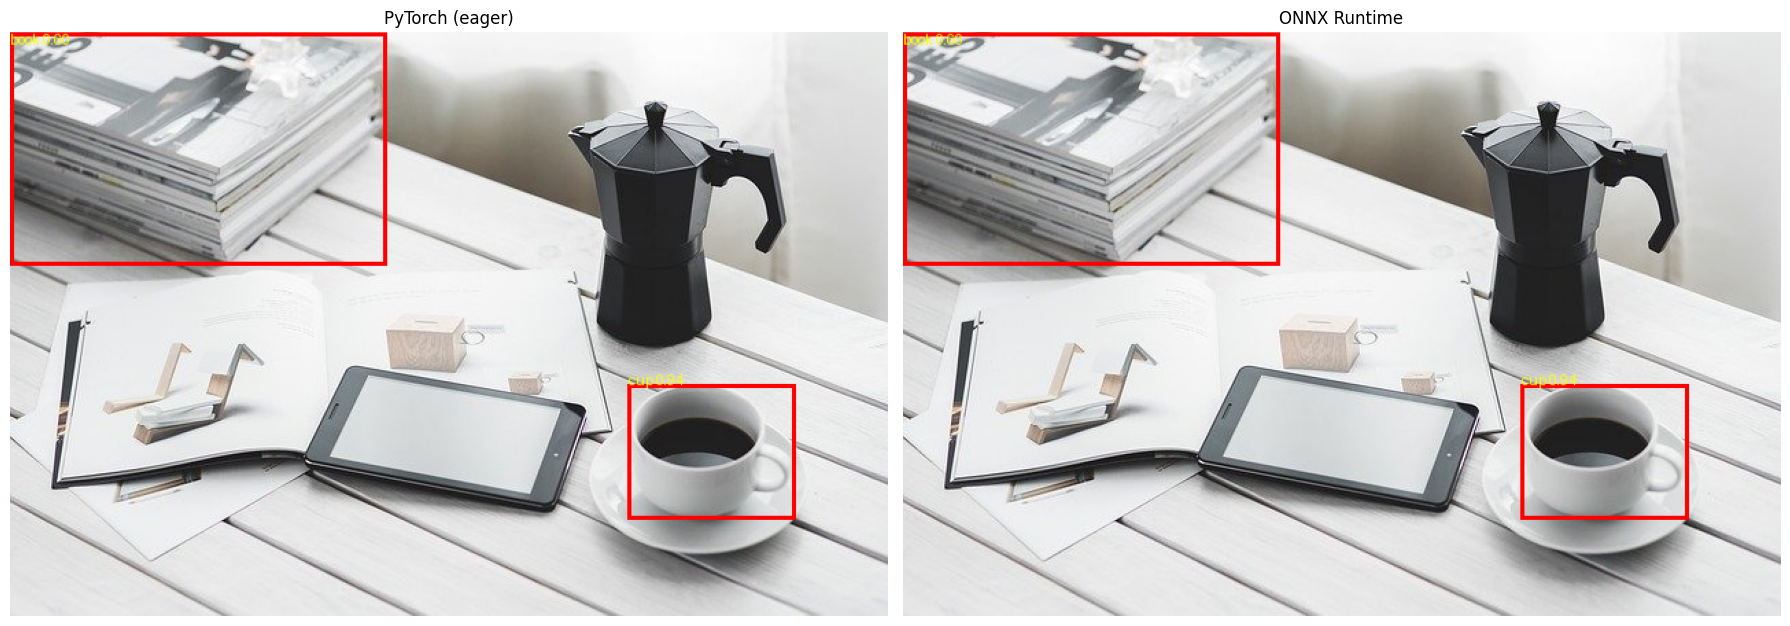

In [29]:
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

# The exported ONNX emits ONLY raw (pred_logits, pred_boxes), so run the SAME postprocessor
# (from the RT-DETR config) on BOTH paths. It has no weights; deploy() is all we need.
postprocessor = config.postprocessor.deploy()
orig_size = torch.tensor([[orig_w, orig_h]], device="cuda")   # [w, h], like tools/infer.py

# model label index 0..79 -> COCO-80 name (remap_mscoco_category=False -> contiguous ids)
COCO = ['person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
        'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
        'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella',
        'handbag','tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
        'baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle',
        'wine glass','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange',
        'broccoli','carrot','hot dog','pizza','donut','cake','chair','couch','potted plant',
        'bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone',
        'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors',
        'teddy bear','hair drier','toothbrush']

def detect(pred_logits, pred_boxes):
    """Shared postprocessor: raw outputs -> (labels, boxes[xyxy px], scores) as numpy."""
    out = {"pred_logits": pred_logits, "pred_boxes": pred_boxes}
    labels, boxes, scores = postprocessor(out, orig_size)   # deploy mode -> batched tensors
    # detach: params keep requires_grad even in eval, so postprocessor outputs may track grad
    return (labels[0].detach().cpu().numpy(),
            boxes[0].detach().cpu().numpy(),
            scores[0].detach().cpu().numpy())

# Torch: model_output is a dict of CUDA tensors.  ONNX: numpy in export order [logits, boxes].
t_labels, t_boxes, t_scores = detect(model_output["pred_logits"], model_output["pred_boxes"])
o_labels, o_boxes, o_scores = detect(torch.from_numpy(ort_outputs[0]).cuda(),
                                     torch.from_numpy(ort_outputs[1]).cuda())

THR = 0.6
def show(name, labels, boxes, scores):
    keep = scores > THR
    print(f"=== {name}: {int(keep.sum())} detections (score > {THR}) ===")
    for lab, box, sc in sorted(zip(labels[keep], boxes[keep], scores[keep]), key=lambda t: -t[2]):
        print(f"  {COCO[int(lab)]:<15s} {sc:.3f}  [{box[0]:6.1f},{box[1]:6.1f},{box[2]:6.1f},{box[3]:6.1f}]")

def draw(base, labels, boxes, scores):
    im = base.copy(); d = ImageDraw.Draw(im); keep = scores > THR
    for lab, box, sc in zip(labels[keep], boxes[keep], scores[keep]):
        d.rectangle([float(v) for v in box], outline="red", width=3)
        d.text((box[0], max(0, box[1] - 10)), f"{COCO[int(lab)]} {sc:.2f}",
               fill="yellow", font=ImageFont.load_default())
    return im

show("PyTorch", t_labels, t_boxes, t_scores)
show("ONNX",    o_labels, o_boxes, o_scores)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].imshow(draw(orig_pil, t_labels, t_boxes, t_scores)); axes[0].set_title("PyTorch (eager)"); axes[0].axis("off")
axes[1].imshow(draw(orig_pil, o_labels, o_boxes, o_scores)); axes[1].set_title("ONNX Runtime");    axes[1].axis("off")
plt.tight_layout(); plt.show()

## Experimentation with Polygraphy

In [117]:
from polygraphy.backend.trt import TrtRunner, CreateConfig, engine_bytes_from_network, network_from_onnx_path, engine_from_bytes
import tensorrt as trt
from pathlib import Path
import numpy as np

In [120]:
from harness.trt_runner import build_engine, TRTSession

In [122]:
engine = build_engine("../models/rtdetr/model.onnx")
sess = TRTSession(engine)

[I] Configuring with profiles:[
        Profile 0:
            {images [min=[1, 3, 640, 640], opt=[1, 3, 640, 640], max=[1, 3, 640, 640]]}
    ]
[I] Building engine with configuration:
    Flags                  | [TF32, STRONGLY_TYPED]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 5799.62 MiB, TACTIC_DRAM: 5799.62 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
[I] Finished engine building in 35.410 seconds


In [127]:
sess.run(np.random.rand(1, 3, 640, 640).astype(np.float32))

{'pred_logits': array([[[-3.3068771, -3.6930342, -2.5210366, ..., -2.4950786,
          -5.3297734, -3.9238176],
         [-2.3661878, -3.411895 , -1.8555493, ..., -2.8444319,
          -4.1047883, -3.03738  ],
         [-4.2294693, -4.2138166, -3.338107 , ..., -3.7852745,
          -6.0510693, -4.5786467],
         ...,
         [-4.7360697, -5.867277 , -5.099872 , ..., -6.077632 ,
          -8.021243 , -5.9644594],
         [-5.2849836, -6.207645 , -5.7596383, ..., -5.750656 ,
          -6.7940493, -6.2123985],
         [-5.294682 , -6.274292 , -5.734291 , ..., -5.7622004,
          -7.1579127, -6.3515396]]], shape=(1, 300, 80), dtype=float32),
 'pred_boxes': array([[[0.50078523, 0.5008133 , 0.99999714, 0.99996984],
         [0.50119555, 0.49757925, 0.99999034, 0.9999695 ],
         [0.49806702, 0.49798954, 0.99998975, 0.999974  ],
         ...,
         [0.963841  , 0.95810854, 0.07213173, 0.078487  ],
         [0.15710364, 0.51827127, 0.1307555 , 0.17889254],
         [0.95668954, 

In [147]:
builder = trt.Builder(trt.Logger(trt.Logger.ERROR))

In [150]:
config = builder.create_builder_config()